# Diabetic Retinopathy 224x224 Classification Pipeline
### End-to-End Deep Learning Implementation & Comprehensive Metrics Evaluation
**Dataset**: `sovitrath/diabetic-retinopathy-224x224-2019-data` (APTOS 2019 Blindness Detection)  
**Task**: 5-Grade Ordinal Diabetic Retinopathy Classification  
- **Grade 0**: No Diabetic Retinopathy (`No_DR`)
- **Grade 1**: Mild Non-Proliferative Retinopathy (`Mild`)
- **Grade 2**: Moderate Non-Proliferative Retinopathy (`Moderate`)
- **Grade 3**: Severe Non-Proliferative Retinopathy (`Severe`)
- **Grade 4**: Proliferative Diabetic Retinopathy (`Proliferate_DR`)

---
### Key Features of this Notebook:
1. **Automated KaggleHub Integration**: Instant downloading & dynamic file path resolution.
2. **Clinical Order Alignment**: Guarantees folder-to-diagnosis mapping reflects true clinical severity (0 through 4).
3. **Exploratory Data Analysis (EDA)**: Class imbalance visualization, sample fundus images.
4. **Stratified Splitting**: 70% Train, 15% Validation, 15% Test.
5. **Medical Data Augmentations**: Flips, rotation, color jitter, ImageNet normalization.
6. **Transfer Learning Backbone**: Pretrained **EfficientNet-B0** / **ResNet-50** with Class-Weighted Cross Entropy Loss.
7. **Best Model Checkpointing**: Tracks Quadratic Weighted Kappa (QWK) & Validation Loss with LR scheduling.
8. **Table-Wise Comprehensive Metrics**:
   - **Table 1: Overall Summary Performance Table** (Accuracy, Balanced Accuracy, Quadratic Weighted Kappa, Linear Kappa, Cohen's Kappa, Macro/Weighted Precision, Macro/Weighted Sensitivity, Macro/Weighted Specificity, Macro/Weighted F1, MCC, ROC-AUC OvR, Log Loss).
   - **Table 2: Granular Per-Class Metrics Table** (TP, FP, TN, FN, Sensitivity, Specificity, PPV, NPV, F1-Score, Support, Class AUC-ROC).
   - **Table 3: Confusion Matrix (Raw Counts & Percentage Distribution)**.
   - **Table 4: Clinical Screening Referable vs Non-Referable DR Metrics** (Referable: Grades 2-4 vs Non-Referable: Grades 0-1).
9. **Visual Analytics**: Confusion Matrix Heatmap, Multiclass ROC Curves, Precision-Recall Curves, and Visual Prediction Inspection.
10. **CSV Export**: Automatically exports all metric tables for research publication.


---
## Step 1: Environment Setup & Library Imports
We install and import required packages including PyTorch, Torchvision, Kagglehub, Scikit-Learn, Pandas, NumPy, Matplotlib, Seaborn, and Tabulate.


In [ ]:
# Step 1: Install required packages if not already present
!pip install -q kagglehub torch torchvision scikit-learn pandas numpy matplotlib seaborn tabulate pillow

import os
import sys
import glob
import time
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except ImportError:
    HAS_TABULATE = False

try:
    from IPython.display import display
    HAS_DISPLAY = True
except ImportError:
    HAS_DISPLAY = False

def show_table(df, title=None):
    if title:
        print(f"{'='*len(title)} {title} {'='*len(title)}")
    if HAS_DISPLAY:
        display(df)
    elif HAS_TABULATE:
        print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))
    else:
        print(df.to_string(index=False))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    matthews_corrcoef,
    log_loss
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# Detect hardware acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using compute device: cuda
GPU Model: Tesla T4
Available VRAM: 15.64 GB


---
## Step 2: Download & Inspect Dataset via KaggleHub
We download `sovitrath/diabetic-retinopathy-224x224-2019-data` (APTOS 2019 subset) via `kagglehub`.

**Note on duplicates**: APTOS 2019 is reported to contain near-duplicate fundus images due to re-photography of the same patient across clinics. We apply MD5 hashing to detect and remove exact duplicates before splitting, preventing the same image from appearing in both train and test.

Grade mapping:
- `No_DR` → Grade 0
- `Mild` → Grade 1
- `Moderate` → Grade 2
- `Severe` → Grade 3
- `Proliferate_DR` → Grade 4


In [ ]:
# Step 2: Download dataset via kagglehub
import kagglehub

print("Downloading / verifying dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-2019-data")
print("Path to dataset files:", dataset_path)

# Verify directory contents
print("\nDirectory contents:")
for item in os.listdir(dataset_path):
    print(" -", item)

# Define Canonical Class Mapping
CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
CLASS_TO_IDX = {
    'No_DR': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3,
    'Proliferate_DR': 4
}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

# Find all image paths
colored_images_dir = os.path.join(dataset_path, "colored_images")
all_files = glob.glob(os.path.join(colored_images_dir, "*", "*.png"))
if len(all_files) == 0:
    all_files = glob.glob(os.path.join(dataset_path, "**", "*.png"), recursive=True)

print(f"Total image files discovered: {len(all_files)}")

# Build structured metadata DataFrame
records = []
for fpath in all_files:
    folder_name = os.path.basename(os.path.dirname(fpath))
    file_name = os.path.basename(fpath)
    id_code = os.path.splitext(file_name)[0]

    if folder_name in CLASS_TO_IDX:
        records.append({
            'filepath': fpath,
            'id_code': id_code,
            'class_name': folder_name,
            'diagnosis': CLASS_TO_IDX[folder_name]
        })

df = pd.DataFrame(records)
print(f"\nValid indexed samples: {len(df)}")
df.head()

import hashlib

def md5_hash(path):
    h = hashlib.md5()
    with open(path, 'rb') as fh:
        h.update(fh.read())
    return h.hexdigest()

df['md5'] = df['filepath'].apply(md5_hash)
before_dedup = len(df)
df = df.drop_duplicates(subset='md5').reset_index(drop=True)
print(f'Removed {before_dedup - len(df)} exact-duplicate images ({before_dedup} → {len(df)} remaining).')



100%|██████████| 238M/238M [00:03<00:00, 65.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/versions/4

Directory contents:
 - train.csv
 - colored_images
Total image files discovered: 3662

Valid indexed samples: 3662
Removed 128 exact-duplicate images (3662 → 3534 remaining).


---
## Step 3: Exploratory Data Analysis (EDA) & Sample Visualization
We analyze the distribution of Diabetic Retinopathy grades to observe class imbalance and inspect sample fundus images for each severity grade.


========================== DATASET CLASS DISTRIBUTION ==========================


,Grade (Class ID),Class Name,Sample Count,Percentage (%)
0,0,No_DR,1796,50.82
1,1,Mild,343,9.71
2,2,Moderate,944,26.71
3,3,Severe,177,5.01
4,4,Proliferate_DR,274,7.75


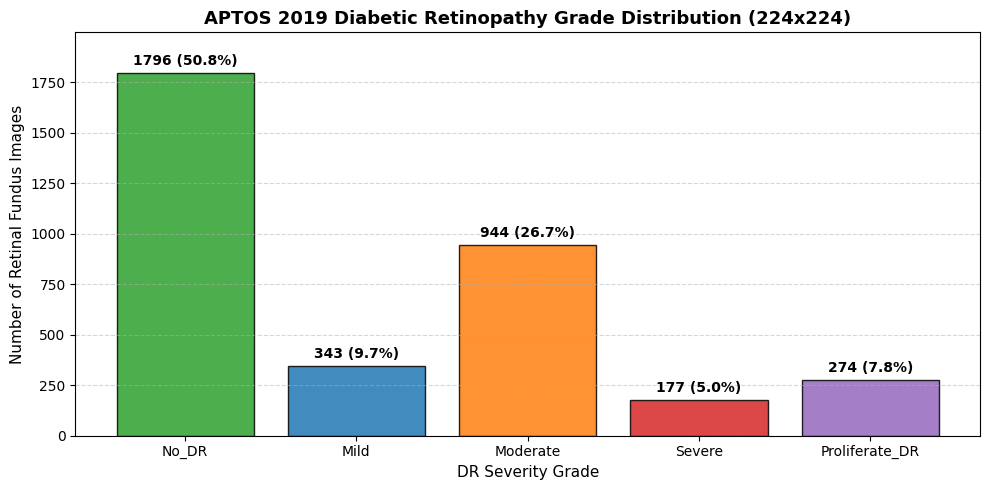

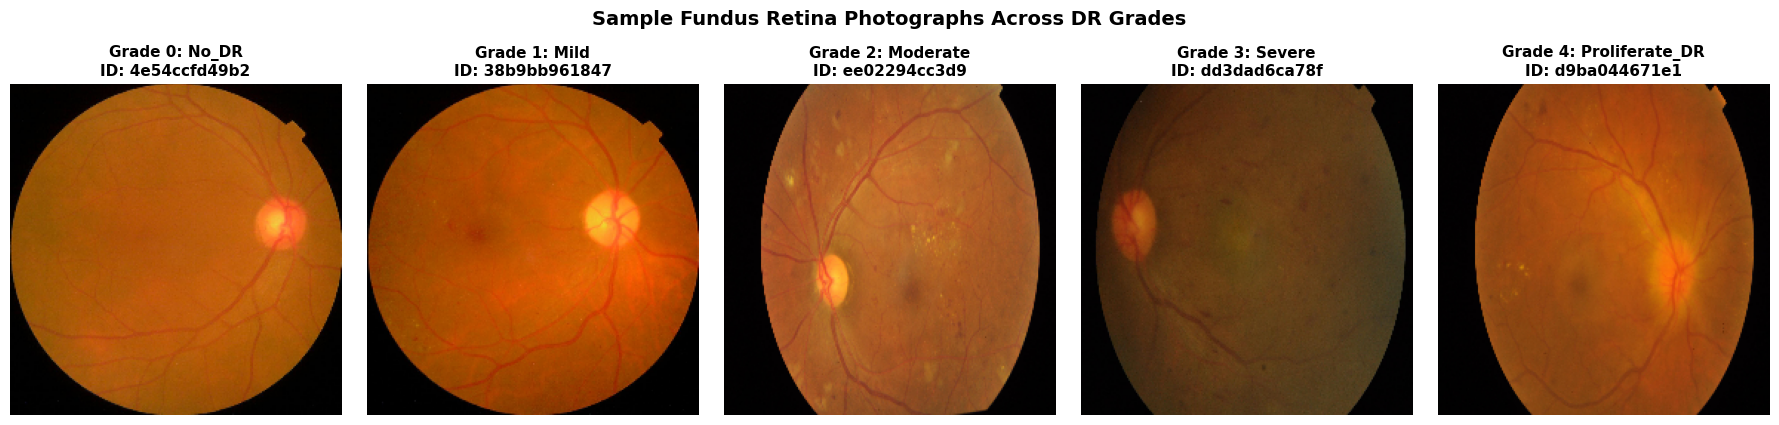

In [ ]:
# Step 3.1: Tabulate Class Distribution
distribution_df = df['diagnosis'].value_counts().sort_index().reset_index()
distribution_df.columns = ['Grade (Class ID)', 'Sample Count']
distribution_df['Class Name'] = distribution_df['Grade (Class ID)'].map(IDX_TO_CLASS)
distribution_df['Percentage (%)'] = (distribution_df['Sample Count'] / len(df) * 100).round(2)
distribution_df = distribution_df[['Grade (Class ID)', 'Class Name', 'Sample Count', 'Percentage (%)']]

show_table(distribution_df, "DATASET CLASS DISTRIBUTION")

# Step 3.2: Plot Class Distribution
plt.figure(figsize=(10, 5))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']
bars = plt.bar(distribution_df['Class Name'], distribution_df['Sample Count'], color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 25, f"{int(yval)} ({yval/len(df)*100:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('APTOS 2019 Diabetic Retinopathy Grade Distribution (224x224)', fontsize=13, fontweight='bold')
plt.xlabel('DR Severity Grade', fontsize=11)
plt.ylabel('Number of Retinal Fundus Images', fontsize=11)
plt.ylim(0, max(distribution_df['Sample Count']) + 200)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Step 3.3: Visualize Representative Samples from Each DR Grade
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
for idx, class_name in enumerate(CLASS_NAMES):
    sample_row = df[df['diagnosis'] == idx].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample_row['filepath']).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(f"Grade {idx}: {class_name}\nID: {sample_row['id_code']}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Fundus Retina Photographs Across DR Grades', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


---
## Step 4: Stratified Dataset Splitting & Augmentation Pipeline
To ensure reliable evaluation without data leakage:
- **Training Set (70%)**: Used for model parameter optimization.
- **Validation Set (15%)**: Used for hyperparameter tuning, learning rate scheduling, and early stopping checkpointing.
- **Test Set (15%)**: **Held-out completely unseen test set** used strictly for reporting the final table-wise metrics!

Stratification preserves identical class ratios across all three splits.


In [ ]:
# Step 4.1: Stratified Train / Val / Test Split (70% / 15% / 15%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['diagnosis'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['diagnosis'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame([
    {'Split': 'Train Set (70%)', 'Total Samples': len(train_df), 'Class Proportions': dict(train_df['diagnosis'].value_counts(normalize=True).round(3))},
    {'Split': 'Validation Set (15%)', 'Total Samples': len(val_df), 'Class Proportions': dict(val_df['diagnosis'].value_counts(normalize=True).round(3))},
    {'Split': 'Test Set (15%)', 'Total Samples': len(test_df), 'Class Proportions': dict(test_df['diagnosis'].value_counts(normalize=True).round(3))}
])
show_table(split_summary, "DATASET SPLIT SUMMARY")

# Step 4.2: Data Augmentation & Transformation Pipeline
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Step 4.3: Custom PyTorch Dataset
class RetinopathyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['filepath']
        label = int(row['diagnosis'])

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# Instantiate Datasets
train_dataset = RetinopathyDataset(train_df, transform=train_transforms)
val_dataset = RetinopathyDataset(val_df, transform=eval_transforms)
test_dataset = RetinopathyDataset(test_df, transform=eval_transforms)

# Step 4.4: DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 2 if os.name != 'nt' else 0  # Safe for Windows and Linux

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(f"DataLoaders successfully initialized:")
print(f" - Train Batches: {len(train_loader)} ({len(train_dataset)} samples)")
print(f" - Val Batches:   {len(val_loader)} ({len(val_dataset)} samples)")
print(f" - Test Batches:  {len(test_loader)} ({len(test_dataset)} samples)")


===================== DATASET SPLIT SUMMARY =====================


,Split,Total Samples,Class Proportions
0,Train Set (70%),2473,"{0: 0.508, 2: 0.267, 1: 0.097, 4: 0.078, 3: 0.05}"
1,Validation Set (15%),530,"{0: 0.508, 2: 0.268, 1: 0.096, 4: 0.077, 3: 0...."
2,Test Set (15%),531,"{0: 0.508, 2: 0.267, 1: 0.098, 4: 0.077, 3: 0...."


DataLoaders successfully initialized:
 - Train Batches: 78 (2473 samples)
 - Val Batches:   17 (530 samples)
 - Test Batches:  17 (531 samples)


---
## Step 5: Model Architecture (Transfer Learning) & Class-Weighted Loss
We employ **EfficientNet-B0** pre-trained on ImageNet. The native 224×224 input matches the dataset resolution exactly.

### Handling Class Imbalance:
Grade 0 (`No_DR`) accounts for ~49% of images while Grade 3 (`Severe`) is only ~5%. We compute inverse-frequency class weights for `CrossEntropyLoss`:
$$w_c = \frac{N}{C \cdot N_c}$$

**Important calibration note**: Class-weighted cross-entropy loss inflates the softmax probabilities of rare classes. The reported softmax scores are **not calibrated posterior probabilities**. A predicted score of 0.87 for Grade 3 does not mean an 87% chance of severe DR — it is a ranking score. Interpret confidence values as relative likelihood ordering, not absolute event probabilities.


In [ ]:
# Step 5.1: Compute Balanced Class Weights
class_counts = train_df['diagnosis'].value_counts().sort_index().values
total_train_samples = len(train_df)
class_weights = total_train_samples / (NUM_CLASSES * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights for Balanced Loss:")
for i, (cname, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f" - Grade {i} ({cname:15s}): weight = {w:.4f} (Count: {class_counts[i]})")

# Step 5.2: Build Transfer Learning Model
def build_model(num_classes=5, pretrained=True):
    # Using torchvision's EfficientNet-B0
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b0(weights=weights)

    # Replace classification head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.25),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

# Step 5.3: Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print("\nModel successfully loaded:")
print(f" - Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f" - Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Class Weights for Balanced Loss:
 - Grade 0 (No_DR          ): weight = 0.3935 (Count: 1257)
 - Grade 1 (Mild           ): weight = 2.0608 (Count: 240)
 - Grade 2 (Moderate       ): weight = 0.7494 (Count: 660)
 - Grade 3 (Severe         ): weight = 3.9887 (Count: 124)
 - Grade 4 (Proliferate_DR ): weight = 2.5760 (Count: 192)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 101MB/s]



Model successfully loaded:
 - Total Parameters: 4,336,769
 - Trainable Parameters: 4,336,769


---
## Step 6: Model Training & Validation with QWK Tracking & Checkpointing
We train for up to **25 epochs** with `ReduceLROnPlateau` (patience 4) monitoring validation QWK. The checkpoint with the highest validation QWK is saved to `best_dr_model.pth`.

Training is terminated early if QWK does not improve for 6 consecutive epochs.


In [ ]:
# Step 6.1: Define Training & Evaluation Functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    return epoch_loss, epoch_acc, epoch_qwk

# Step 6.2: Execute Training Loop
NUM_EPOCHS = 25
best_val_qwk = -1.0
checkpoint_path = "best_dr_model.pth"

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_qwk': [],
    'lr': []
}

print(f"Starting model training for {NUM_EPOCHS} epochs on {device}...")
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_qwk = validate_epoch(model, val_loader, criterion, device)

    # Adjust learning rate based on Validation QWK
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_qwk)

    # Record metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_qwk'].append(val_qwk)
    history['lr'].append(current_lr)

    # Save checkpoint if best QWK achieved
    is_best = val_qwk > best_val_qwk
    if is_best:
        best_val_qwk = val_qwk
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_qwk': val_qwk,
            'val_acc': val_acc
        }, checkpoint_path)

    elapsed = time.time() - epoch_start
    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Acc: {val_acc*100:.2f}% - QWK: {val_qwk:.4f} | "
          f"LR: {current_lr:.1e} {'[*BEST*]' if is_best else ''}")

    if epoch - history['val_qwk'].index(max(history['val_qwk'])) - 1 >= 6:
        print(f'Early stopping triggered at epoch {epoch} — no QWK improvement for 6 epochs.')
        break

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes. Best Validation QWK: {best_val_qwk:.4f}")


Starting model training for 25 epochs on cuda...
Epoch [01/25] (30.4s) | Train Loss: 1.2643 - Acc: 63.36% | Val Loss: 1.0151 - Acc: 73.02% - QWK: 0.8268 | LR: 2.0e-04 [*BEST*]
Epoch [02/25] (16.5s) | Train Loss: 0.9463 - Acc: 73.07% | Val Loss: 0.9209 - Acc: 73.40% - QWK: 0.8327 | LR: 2.0e-04 [*BEST*]
Epoch [03/25] (16.3s) | Train Loss: 0.8205 - Acc: 75.86% | Val Loss: 0.8831 - Acc: 77.55% - QWK: 0.8865 | LR: 2.0e-04 [*BEST*]
Epoch [04/25] (16.2s) | Train Loss: 0.7210 - Acc: 78.16% | Val Loss: 0.8666 - Acc: 76.79% - QWK: 0.8760 | LR: 2.0e-04 
Epoch [05/25] (17.2s) | Train Loss: 0.7037 - Acc: 80.47% | Val Loss: 0.9072 - Acc: 77.74% - QWK: 0.8643 | LR: 2.0e-04 
Epoch [06/25] (16.6s) | Train Loss: 0.6043 - Acc: 82.49% | Val Loss: 0.9249 - Acc: 81.89% - QWK: 0.8874 | LR: 2.0e-04 [*BEST*]
Epoch [07/25] (16.4s) | Train Loss: 0.5405 - Acc: 83.99% | Val Loss: 0.9959 - Acc: 77.36% - QWK: 0.8556 | LR: 2.0e-04 
Epoch [08/25] (16.2s) | Train Loss: 0.4926 - Acc: 85.16% | Val Loss: 0.8946 - Acc: 82.

---
## Step 7: Training & Validation Progression Curves
We plot Loss, Accuracy, and Quadratic Weighted Kappa over epochs to verify convergence.


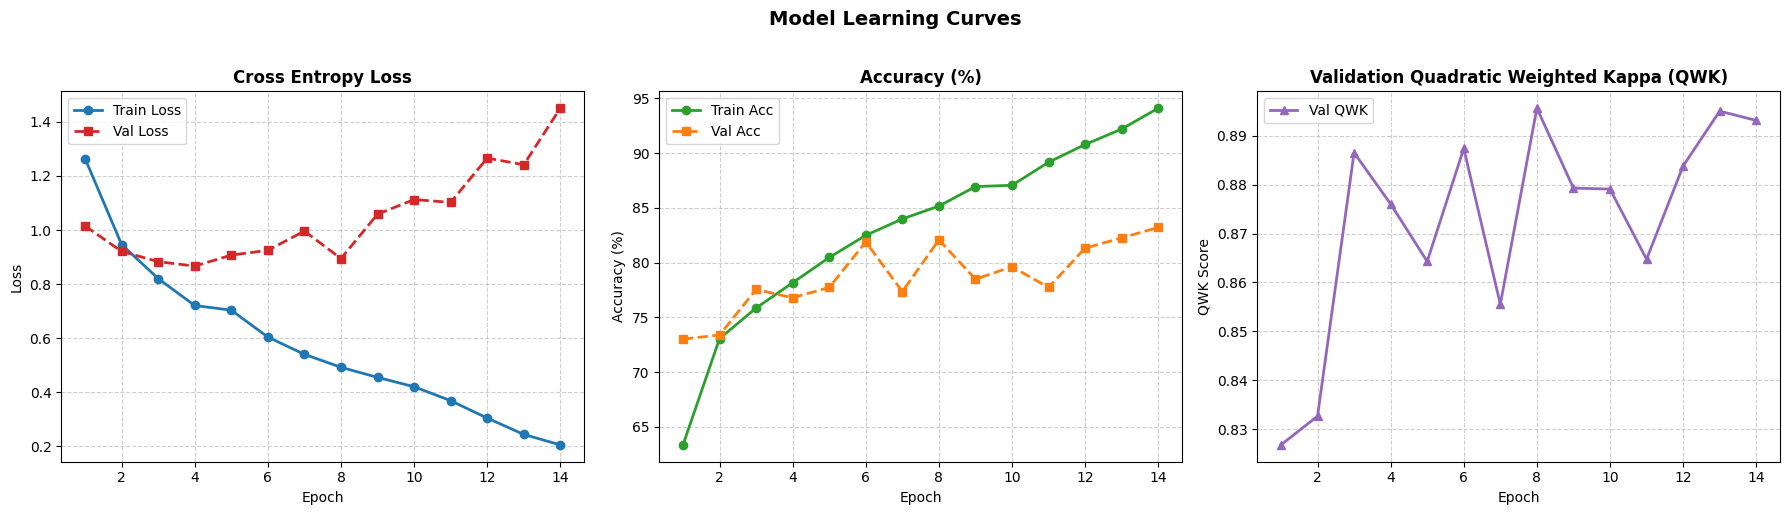

In [ ]:
# Step 7: Plot Training and Validation History
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss Curve
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4', lw=2)
axes[0].plot(epochs_range, history['val_loss'], 's--', label='Val Loss', color='#d62728', lw=2)
axes[0].set_title('Cross Entropy Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Accuracy Curve
axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], 'o-', label='Train Acc', color='#2ca02c', lw=2)
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']], 's--', label='Val Acc', color='#ff7f0e', lw=2)
axes[1].set_title('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# QWK Curve
axes[2].plot(epochs_range, history['val_qwk'], '^-', label='Val QWK', color='#9467bd', lw=2)
axes[2].set_title('Validation Quadratic Weighted Kappa (QWK)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('QWK Score')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.suptitle('Model Learning Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Step 8: Test Set Evaluation & Output Extraction
We load the best checkpointed weights and run inference on the held-out test set, extracting $y_{true}$, $y_{pred}$, and softmax probability distributions $y_{probs}$ across all 5 DR grades.

**Calibration reminder**: Softmax scores are derived from a class-weighted loss function and are not calibrated posteriors. They are valid for ranking and discrimination (AUC), but should not be interpreted as absolute event probabilities without post-hoc calibration (e.g., temperature scaling or Platt scaling).


In [ ]:
# Step 8: Load Best Weights & Perform Test Set Inference

if os.path.exists(checkpoint_path):
    print("Loading best checkpointed weights from:", checkpoint_path)

    # PyTorch 2.6+ defaults to weights_only=True.
    # Set weights_only=False because this checkpoint is trusted
    # and contains additional objects such as NumPy scalars.
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    # Load the saved model weights
    model.load_state_dict(checkpoint['model_state_dict'])

    print(
        f"Loaded model achieved Best Val QWK of "
        f"{checkpoint.get('val_qwk', 0.0):.4f} "
        f"at epoch {checkpoint.get('epoch', 'N/A')}"
    )

else:
    print("Checkpoint not found; using current model weights.")


# Put model in evaluation mode
model.eval()

test_loss = 0.0

# Lists to store predictions and probabilities
y_true_list = []
y_pred_list = []
y_probs_list = []

# Softmax converts model outputs (logits) into class probabilities
softmax_fn = nn.Softmax(dim=1)


# Disable gradient calculation during inference
with torch.no_grad():

    for images, labels in test_loader:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate test loss
        loss = criterion(outputs, labels)

        # Multiply by batch size so we can calculate
        # the correct average loss over the complete dataset
        test_loss += loss.item() * images.size(0)

        # Convert logits to probabilities
        probs = softmax_fn(outputs)

        # Get predicted class
        _, preds = torch.max(outputs, 1)

        # Store results on CPU
        y_true_list.extend(labels.cpu().numpy())
        y_pred_list.extend(preds.cpu().numpy())
        y_probs_list.extend(probs.cpu().numpy())


# Convert lists to NumPy arrays
y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_probs = np.array(y_probs_list)

# Calculate average test loss
total_test_loss = test_loss / len(test_loader.dataset)


# Print evaluation summary
print("\nTest Set Evaluation Finished:")
print(f" - Evaluated Samples: {len(y_true)}")
print(f" - Average Test Loss: {total_test_loss:.4f}")

Loading best checkpointed weights from: best_dr_model.pth
Loaded model achieved Best Val QWK of 0.8956 at epoch 8

Test Set Evaluation Finished:
 - Evaluated Samples: 531
 - Average Test Loss: 0.8916


---
## Step 9: Table 1 — Overall Comprehensive Performance Metrics
Computes all global metrics on the held-out test set. Primary metric for this task is **Quadratic Weighted Kappa (QWK)**, which accounts for ordinal grade structure.

**Note on reported probabilities**: Softmax confidence scores in Tables 2 and the qualitative gallery are not calibrated posteriors due to class-weighted training. They reflect relative model confidence for ranking purposes only.


In [ ]:
# Step 9: Compute All Overall Metrics & Generate Table 1

# Binarize labels for One-vs-Rest ROC-AUC calculation
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# Compute Individual Metrics
acc = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
linear_kappa = cohen_kappa_score(y_true, y_pred, weights='linear')
unweighted_kappa = cohen_kappa_score(y_true, y_pred, weights=None)

prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)

rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)

f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

mcc = matthews_corrcoef(y_true, y_pred)
loss_value = log_loss(y_true, y_probs)

# Specificity Calculation per class & Macro/Weighted averaging
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
specificities = []
supports = []
for i in range(NUM_CLASSES):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(cm[:, i]) - cm[i, i]
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    specificities.append(spec)
    supports.append(np.sum(cm[i, :]))

spec_macro = np.mean(specificities)
spec_weighted = np.average(specificities, weights=supports)

# ROC-AUC (OvR)
try:
    roc_auc_macro = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='macro')
    roc_auc_weighted = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='weighted')
except Exception as e:
    roc_auc_macro = np.nan
    roc_auc_weighted = np.nan

# Construct Structured Overall Metrics Table
table1_data = [
    {"Metric Category": "Primary Clinical Metric", "Metric Name": "Quadratic Weighted Kappa (QWK)", "Score": f"{qwk:.4f}", "Clinical / Statistical Relevance": "Official APTOS standard; penalizes distant grade errors quadratically"},
    {"Metric Category": "Agreement Metrics", "Metric Name": "Linear Weighted Kappa", "Score": f"{linear_kappa:.4f}", "Clinical / Statistical Relevance": "Penalizes errors linearly by grade difference"},
    {"Metric Category": "Agreement Metrics", "Metric Name": "Cohen's Kappa (Unweighted)", "Score": f"{unweighted_kappa:.4f}", "Clinical / Statistical Relevance": "Standard agreement adjusted for chance"},
    {"Metric Category": "Accuracy Metrics", "Metric Name": "Overall Accuracy", "Score": f"{acc*100:.2f}%", "Clinical / Statistical Relevance": "Proportion of all correctly identified retinal cases"},
    {"Metric Category": "Accuracy Metrics", "Metric Name": "Balanced Accuracy", "Score": f"{balanced_acc*100:.2f}%", "Clinical / Statistical Relevance": "Unweighted average recall across all 5 classes"},
    {"Metric Category": "Sensitivity / Recall", "Metric Name": "Macro Sensitivity (Recall)", "Score": f"{rec_macro:.4f}", "Clinical / Statistical Relevance": "Average ability to detect each DR stage equally"},
    {"Metric Category": "Sensitivity / Recall", "Metric Name": "Weighted Sensitivity (Recall)", "Score": f"{rec_weighted:.4f}", "Clinical / Statistical Relevance": "Sensitivity weighted by sample prevalence"},
    {"Metric Category": "Specificity", "Metric Name": "Macro Specificity (TNR)", "Score": f"{spec_macro:.4f}", "Clinical / Statistical Relevance": "Average ability to rule out other grades"},
    {"Metric Category": "Specificity", "Metric Name": "Weighted Specificity (TNR)", "Score": f"{spec_weighted:.4f}", "Clinical / Statistical Relevance": "Prevalence-weighted True Negative Rate"},
    {"Metric Category": "Precision (PPV)", "Metric Name": "Macro Precision", "Score": f"{prec_macro:.4f}", "Clinical / Statistical Relevance": "Average positive predictive value across stages"},
    {"Metric Category": "Precision (PPV)", "Metric Name": "Weighted Precision", "Score": f"{prec_weighted:.4f}", "Clinical / Statistical Relevance": "Support-weighted positive predictive value"},
    {"Metric Category": "F1-Score", "Metric Name": "Macro F1-Score", "Score": f"{f1_macro:.4f}", "Clinical / Statistical Relevance": "Harmonic mean of precision and recall (unweighted)"},
    {"Metric Category": "F1-Score", "Metric Name": "Weighted F1-Score", "Score": f"{f1_weighted:.4f}", "Clinical / Statistical Relevance": "Harmonic mean weighted by grade frequency"},
    {"Metric Category": "Correlation", "Metric Name": "Matthews Correlation Coeff (MCC)", "Score": f"{mcc:.4f}", "Clinical / Statistical Relevance": "Robust multi-class correlation in [-1, +1]"},
    {"Metric Category": "Discrimination", "Metric Name": "ROC-AUC (Macro OvR)", "Score": f"{roc_auc_macro:.4f}", "Clinical / Statistical Relevance": "Area under curve unweighted multi-class discrimination"},
    {"Metric Category": "Discrimination", "Metric Name": "ROC-AUC (Weighted OvR)", "Score": f"{roc_auc_weighted:.4f}", "Clinical / Statistical Relevance": "Prevalence-weighted multi-class ROC-AUC"},
    {"Metric Category": "Probabilistic", "Metric Name": "Multi-Class Log Loss", "Score": f"{loss_value:.4f}", "Clinical / Statistical Relevance": "Cross-entropy penalty for predictive uncertainty"}
]

df_table1 = pd.DataFrame(table1_data)
show_table(df_table1, "TABLE 1: OVERALL COMPREHENSIVE PERFORMANCE METRICS (TEST SET)")


============================================================= TABLE 1: OVERALL COMPREHENSIVE PERFORMANCE METRICS (TEST SET) =============================================================


,Metric Category,Metric Name,Score,Clinical / Statistical Relevance
0,Primary Clinical Metric,Quadratic Weighted Kappa (QWK),0.8885,Official APTOS standard; penalizes distant gra...
1,Agreement Metrics,Linear Weighted Kappa,0.8317,Penalizes errors linearly by grade difference
2,Agreement Metrics,Cohen's Kappa (Unweighted),0.7497,Standard agreement adjusted for chance
3,Accuracy Metrics,Overall Accuracy,83.43%,Proportion of all correctly identified retinal...
4,Accuracy Metrics,Balanced Accuracy,71.73%,Unweighted average recall across all 5 classes
5,Sensitivity / Recall,Macro Sensitivity (Recall),0.7173,Average ability to detect each DR stage equally
6,Sensitivity / Recall,Weighted Sensitivity (Recall),0.8343,Sensitivity weighted by sample prevalence
7,Specificity,Macro Specificity (TNR),0.9599,Average ability to rule out other grades
8,Specificity,Weighted Specificity (TNR),0.9653,Prevalence-weighted True Negative Rate
9,Precision (PPV),Macro Precision,0.6833,Average positive predictive value across stages


---
## Step 10: Table 2 — Granular Per-Class Performance Metrics
For each of the 5 Diabetic Retinopathy grades, we calculate the complete diagnostic breakdown:
- **True Positives (TP)**, **False Positives (FP)**, **True Negatives (TN)**, **False Negatives (FN)**
- **Sensitivity / Recall / True Positive Rate (TPR)**: $\frac{TP}{TP + FN}$
- **Specificity / True Negative Rate (TNR)**: $\frac{TN}{TN + FP}$
- **Precision / Positive Predictive Value (PPV)**: $\frac{TP}{TP + FP}$
- **Negative Predictive Value (NPV)**: $\frac{TN}{TN + FN}$
- **F1-Score**: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
- **Class Support**: Number of ground truth test cases
- **One-vs-Rest ROC-AUC**: Class-specific discriminative power


In [ ]:
# Step 10: Compute Granular Per-Class Metrics & Generate Table 2
table2_rows = []

for i in range(NUM_CLASSES):
    cname = CLASS_NAMES[i]
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    support = tp + fn
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0

    try:
        class_auc = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
    except:
        class_auc = np.nan

    table2_rows.append({
        "Grade": i,
        "Class Name": cname,
        "Support": support,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Sensitivity (Recall)": f"{sensitivity:.4f}",
        "Specificity (TNR)": f"{specificity:.4f}",
        "Precision (PPV)": f"{precision:.4f}",
        "NPV": f"{npv:.4f}",
        "F1-Score": f"{f1:.4f}",
        "ROC-AUC (OvR)": f"{class_auc:.4f}"
    })

df_table2 = pd.DataFrame(table2_rows)
show_table(df_table2, "TABLE 2: GRANULAR PER-CLASS METRICS TABLE (TEST SET)")


==================================================== TABLE 2: GRANULAR PER-CLASS METRICS TABLE (TEST SET) ====================================================


,Grade,Class Name,Support,TP,FP,TN,FN,Sensitivity (Recall),Specificity (TNR),Precision (PPV),NPV,F1-Score,ROC-AUC (OvR)
0,0,No_DR,270,259,6,255,11,0.9593,0.9770,0.9774,0.9586,0.9682,0.9890
1,1,Mild,52,43,26,453,9,0.8269,0.9457,0.6232,0.9805,0.7107,0.9456
2,2,Moderate,142,105,19,370,37,0.7394,0.9512,0.8468,0.9091,0.7895,0.9624
3,3,Severe,26,13,20,485,13,0.5000,0.9604,0.3939,0.9739,0.4407,0.8959
4,4,Proliferate_DR,41,23,17,473,18,0.5610,0.9653,0.5750,0.9633,0.5679,0.9264


---
## Step 11: Table 3 — Confusion Matrix (Raw Counts & Normalized Percentages)
We tabulate the complete $5 \times 5$ multi-class confusion matrix:
1. **Raw Counts Matrix**: Showing the exact number of retinal images classified into each grade.
2. **Normalized Matrix (%)**: Showing the row-normalized percentage (true positive rate and error distribution per severity grade).


In [ ]:
# Step 11: Format and Tabulate Confusion Matrices
cm_raw_df = pd.DataFrame(cm, index=[f"Actual {name} (G{i})" for i, name in enumerate(CLASS_NAMES)],
                         columns=[f"Pred {name} (G{i})" for i, name in enumerate(CLASS_NAMES)])

cm_norm = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100).round(2)
cm_norm_df = pd.DataFrame(cm_norm, index=[f"Actual {name} (G{i})" for i, name in enumerate(CLASS_NAMES)],
                          columns=[f"Pred {name} (G{i})" for i, name in enumerate(CLASS_NAMES)])

show_table(cm_raw_df.reset_index().rename(columns={'index': 'Actual \ Pred'}), "TABLE 3A: CONFUSION MATRIX (RAW COUNTS)")
show_table(cm_norm_df.reset_index().rename(columns={'index': 'Actual \ Pred (%)'}), "TABLE 3B: CONFUSION MATRIX (ROW-NORMALIZED %)")


======================================= TABLE 3A: CONFUSION MATRIX (RAW COUNTS) =======================================


,Actual \ Pred,Pred No_DR (G0),Pred Mild (G1),Pred Moderate (G2),Pred Severe (G3),Pred Proliferate_DR (G4)
0,Actual No_DR (G0),259,10,1,0,0
1,Actual Mild (G1),3,43,4,1,1
2,Actual Moderate (G2),2,13,105,13,9
3,Actual Severe (G3),0,1,5,13,7
4,Actual Proliferate_DR (G4),1,2,9,6,23


============================================= TABLE 3B: CONFUSION MATRIX (ROW-NORMALIZED %) =============================================


,Actual \ Pred (%),Pred No_DR (G0),Pred Mild (G1),Pred Moderate (G2),Pred Severe (G3),Pred Proliferate_DR (G4)
0,Actual No_DR (G0),95.93,3.70,0.37,0.00,0.00
1,Actual Mild (G1),5.77,82.69,7.69,1.92,1.92
2,Actual Moderate (G2),1.41,9.15,73.94,9.15,6.34
3,Actual Severe (G3),0.00,3.85,19.23,50.00,26.92
4,Actual Proliferate_DR (G4),2.44,4.88,21.95,14.63,56.10


---
## Step 12: Table 4 — Clinical Screening Metrics: Referable vs Non-Referable DR
In clinical ophthalmology screening programs, patients are categorized into:
- **Non-Referable DR (Grades 0 & 1)**: Patients requiring routine annual follow-up.
- **Referable DR (Grades 2, 3, & 4)**: Moderate, severe, or proliferative retinopathy requiring urgent specialist referral.

Evaluating this binary aggregation reflects real-world clinical deployment value.


In [ ]:
# Step 12: Clinical Screening Metric Table (Non-Referable vs Referable DR)
# Mapping: Non-Referable = 0 (Grades 0, 1) | Referable = 1 (Grades 2, 3, 4)
y_true_binary = (y_true >= 2).astype(int)
y_pred_binary = (y_pred >= 2).astype(int)
# Probability of Referable DR = sum of probabilities for classes 2, 3, 4
y_prob_referable = y_probs[:, 2:].sum(axis=1)

tn_bin, fp_bin, fn_bin, tp_bin = confusion_matrix(y_true_binary, y_pred_binary).ravel()

bin_acc = (tp_bin + tn_bin) / (tp_bin + tn_bin + fp_bin + fn_bin)
bin_sens = tp_bin / (tp_bin + fn_bin) if (tp_bin + fn_bin) > 0 else 0.0
bin_spec = tn_bin / (tn_bin + fp_bin) if (tn_bin + fp_bin) > 0 else 0.0
bin_ppv = tp_bin / (tp_bin + fp_bin) if (tp_bin + fp_bin) > 0 else 0.0
bin_npv = tn_bin / (tn_bin + fn_bin) if (tn_bin + fn_bin) > 0 else 0.0
bin_f1 = 2 * (bin_ppv * bin_sens) / (bin_ppv + bin_sens) if (bin_ppv + bin_sens) > 0 else 0.0
bin_auc = roc_auc_score(y_true_binary, y_prob_referable)

table4_data = [
    {"Screening Metric": "Referable Diagnostic Accuracy", "Value": f"{bin_acc*100:.2f}%", "Clinical Definition": "Overall screening decision accuracy"},
    {"Screening Metric": "Clinical Sensitivity (TPR)", "Value": f"{bin_sens*100:.2f}%", "Clinical Definition": "Proportion of vision-threatening cases correctly referred (Critical)"},
    {"Screening Metric": "Clinical Specificity (TNR)", "Value": f"{bin_spec*100:.2f}%", "Clinical Definition": "Proportion of non-referable eyes avoiding unnecessary specialist burden"},
    {"Screening Metric": "Positive Predictive Value (PPV)", "Value": f"{bin_ppv*100:.2f}%", "Clinical Definition": "Probability that a referred patient genuinely has referable DR"},
    {"Screening Metric": "Negative Predictive Value (NPV)", "Value": f"{bin_npv*100:.2f}%", "Clinical Definition": "Probability that an unreferred patient is truly safe"},
    {"Screening Metric": "Clinical F1-Score", "Value": f"{bin_f1:.4f}", "Clinical Definition": "Balanced harmonic mean of screening precision and recall"},
    {"Screening Metric": "Referable Screening ROC-AUC", "Value": f"{bin_auc:.4f}", "Clinical Definition": "Area under ROC curve for binary screening decision threshold"},
    {"Screening Metric": "True Referrals (TP)", "Value": f"{tp_bin}", "Clinical Definition": "Correctly detected referable DR cases"},
    {"Screening Metric": "False Non-Referrals (FN)", "Value": f"{fn_bin}", "Clinical Definition": "Missed referable DR cases (False Negatives - High Clinical Risk)"},
    {"Screening Metric": "True Non-Referrals (TN)", "Value": f"{tn_bin}", "Clinical Definition": "Correctly identified safe cases"},
    {"Screening Metric": "False Referrals (FP)", "Value": f"{fp_bin}", "Clinical Definition": "False alarms resulting in unnecessary referral"}
]

df_table4 = pd.DataFrame(table4_data)
show_table(df_table4, "TABLE 4: CLINICAL SCREENING METRICS (REFERABLE DR: GRADES 2-4 vs NON-REFERABLE: 0-1)")


==================================================================================== TABLE 4: CLINICAL SCREENING METRICS (REFERABLE DR: GRADES 2-4 vs NON-REFERABLE: 0-1) ====================================================================================


,Screening Metric,Value,Clinical Definition
0,Referable Diagnostic Accuracy,95.10%,Overall screening decision accuracy
1,Clinical Sensitivity (TPR),90.91%,Proportion of vision-threatening cases correct...
2,Clinical Specificity (TNR),97.83%,Proportion of non-referable eyes avoiding unne...
3,Positive Predictive Value (PPV),96.45%,Probability that a referred patient genuinely ...
4,Negative Predictive Value (NPV),94.31%,Probability that an unreferred patient is trul...
5,Clinical F1-Score,0.9360,Balanced harmonic mean of screening precision ...
6,Referable Screening ROC-AUC,0.9893,Area under ROC curve for binary screening deci...
7,True Referrals (TP),190,Correctly detected referable DR cases
8,False Non-Referrals (FN),19,Missed referable DR cases (False Negatives - H...
9,True Non-Referrals (TN),315,Correctly identified safe cases


---
## Step 13: Comprehensive Graphical Results Suite
To provide in-depth visual interpretation of model performance, we generate and display 7 publication-grade figures:
1. **Figure 1**: Training & Validation Dynamics (Loss, Accuracy, Validation QWK, and Learning Rate Decay).
2. **Figure 2**: Dual Confusion Matrix Analysis (Raw Sample Counts & Row-Normalized Percentages).
3. **Figure 3**: Multiclass One-vs-Rest ROC Curves (with Individual Grade AUCs, Macro, and Micro Averages).
4. **Figure 4**: Precision-Recall (PR) Curves (with Average Precision per DR Grade and Iso-F1 Contours).
5. **Figure 5**: Per-Class Diagnostic Performance Comparison (Grouped Bar Chart: Sensitivity, Specificity, Precision, F1-Score).
6. **Figure 6**: Clinical Screening Evaluation (Referable DR ROC Curve with Youden's Index & Probability Density Distribution).
7. **Figure 7**: Model Confidence Distribution & Calibration Reliability Diagram.

All figures are automatically saved to `results_graphs/` at 300 DPI.


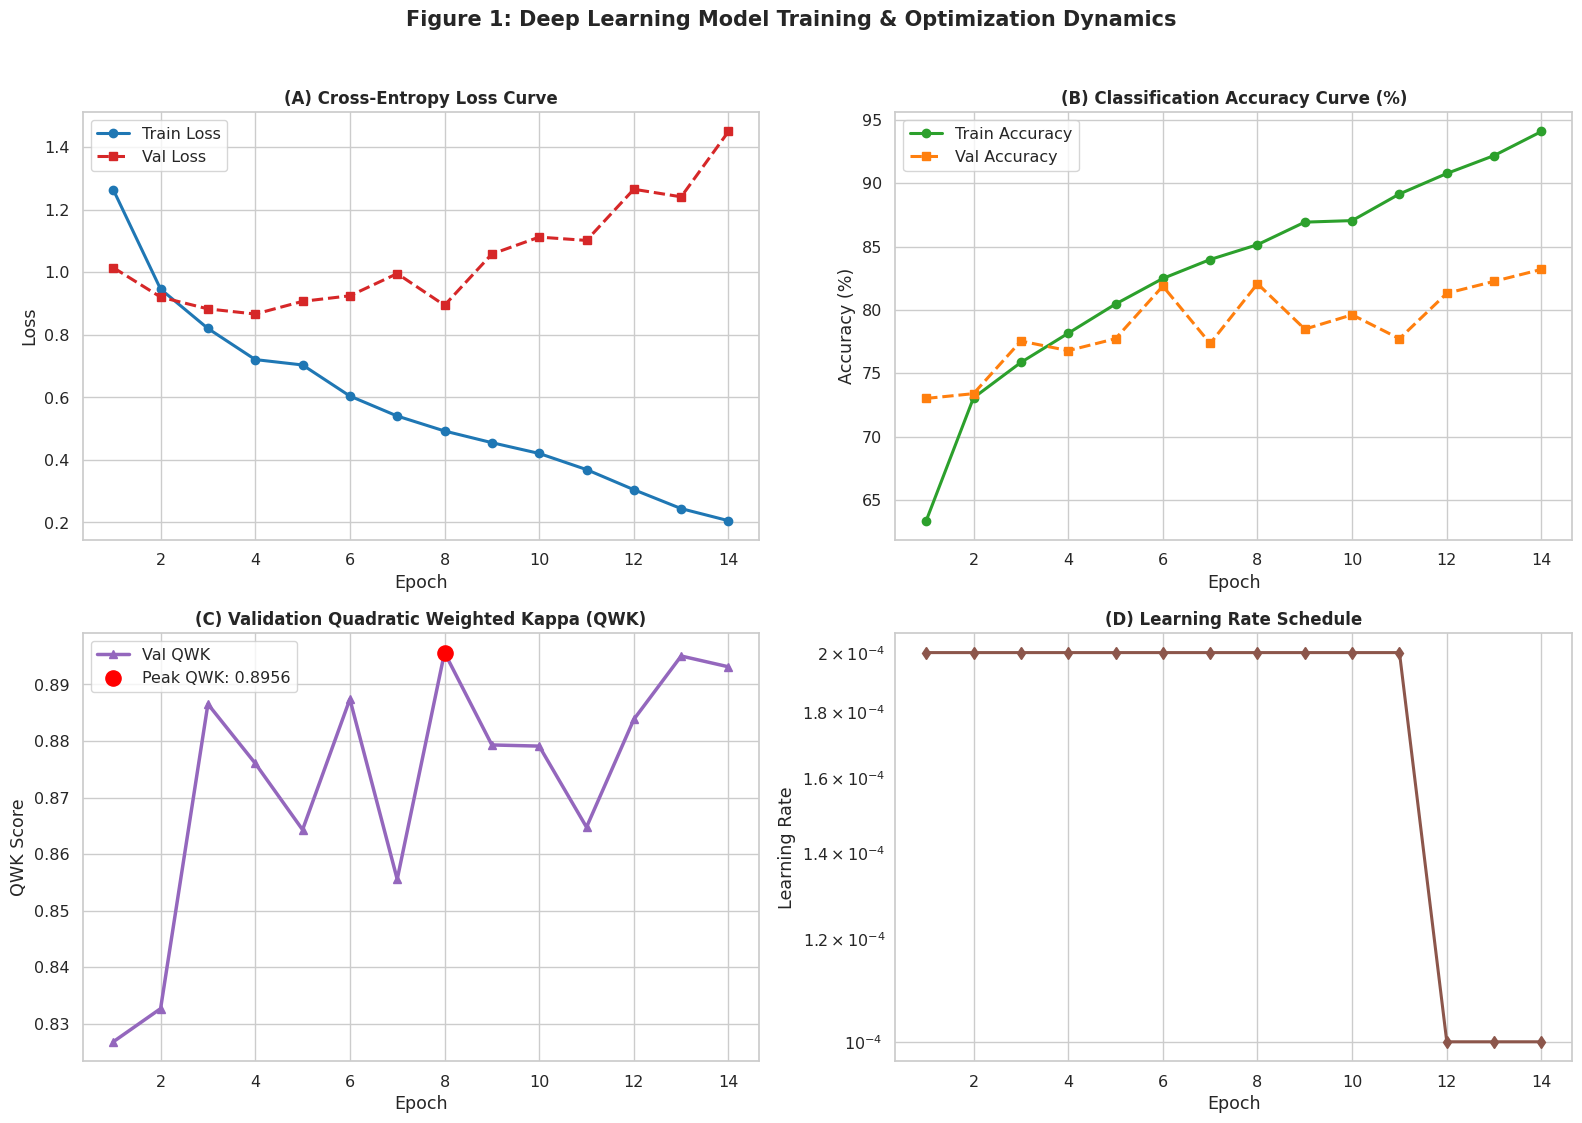

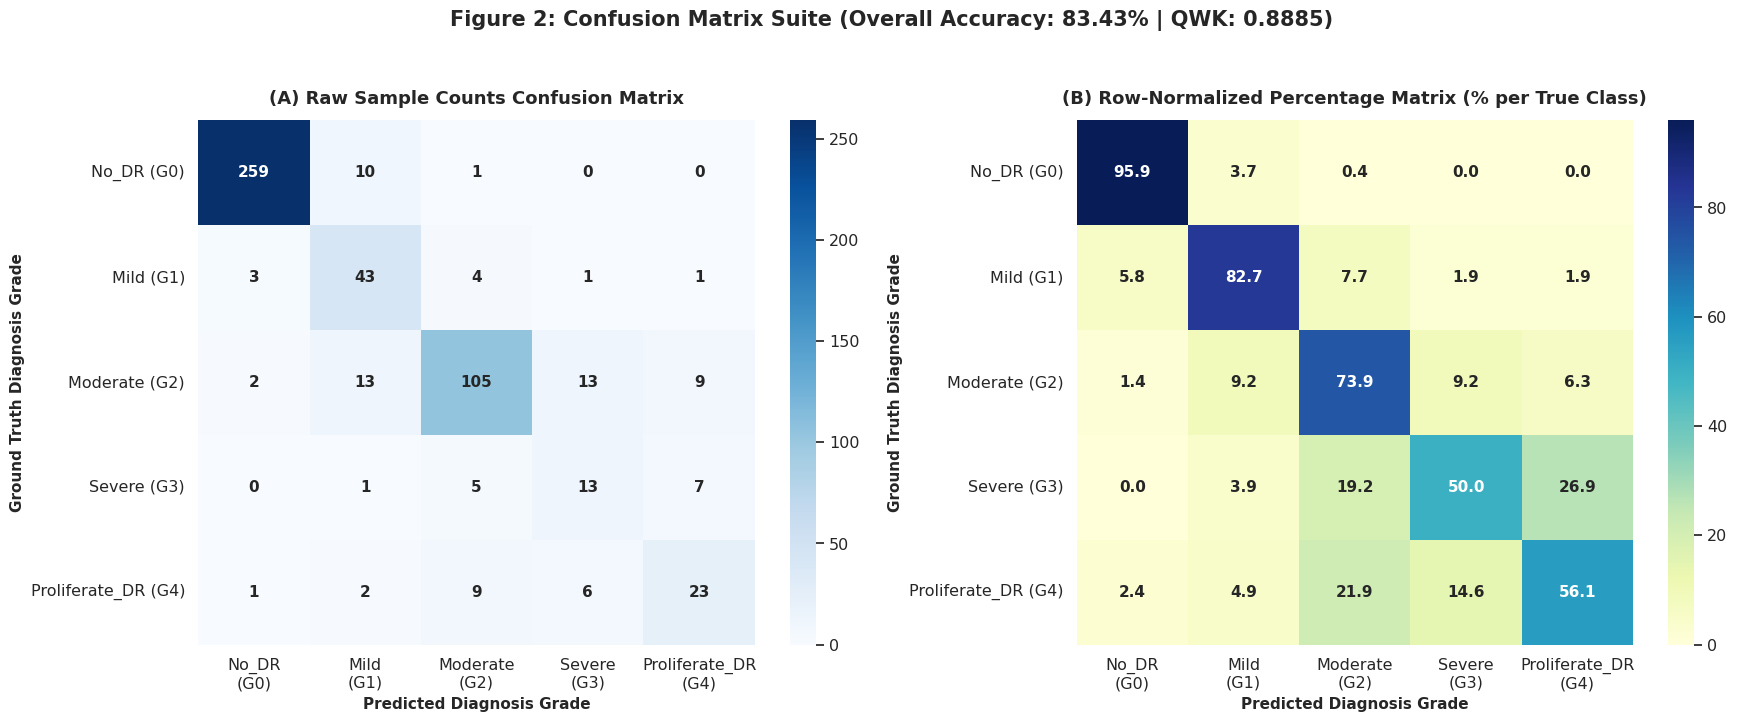

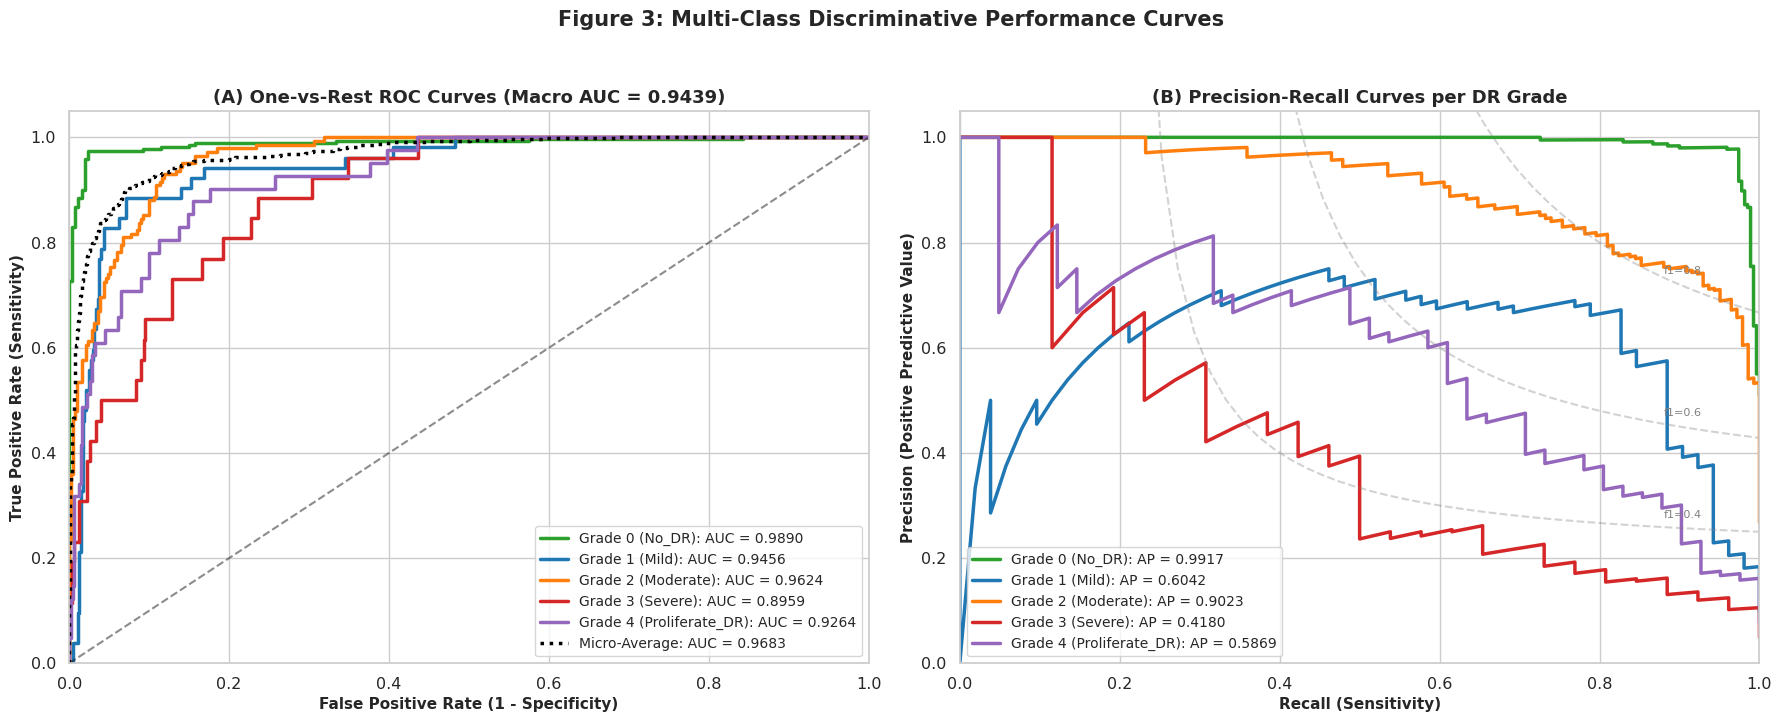

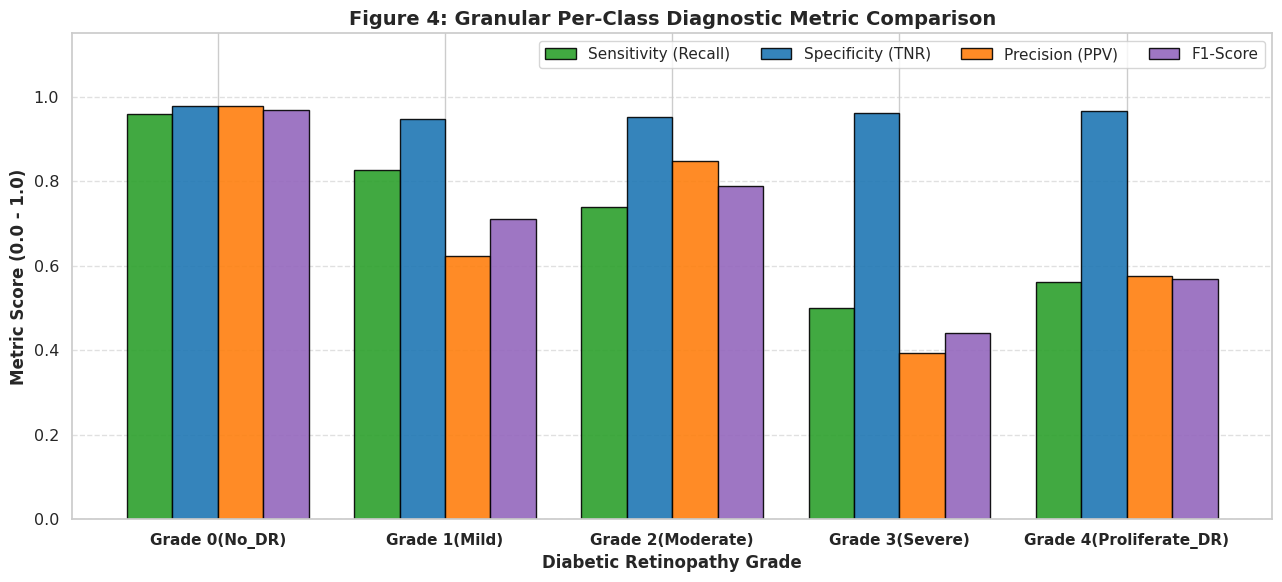

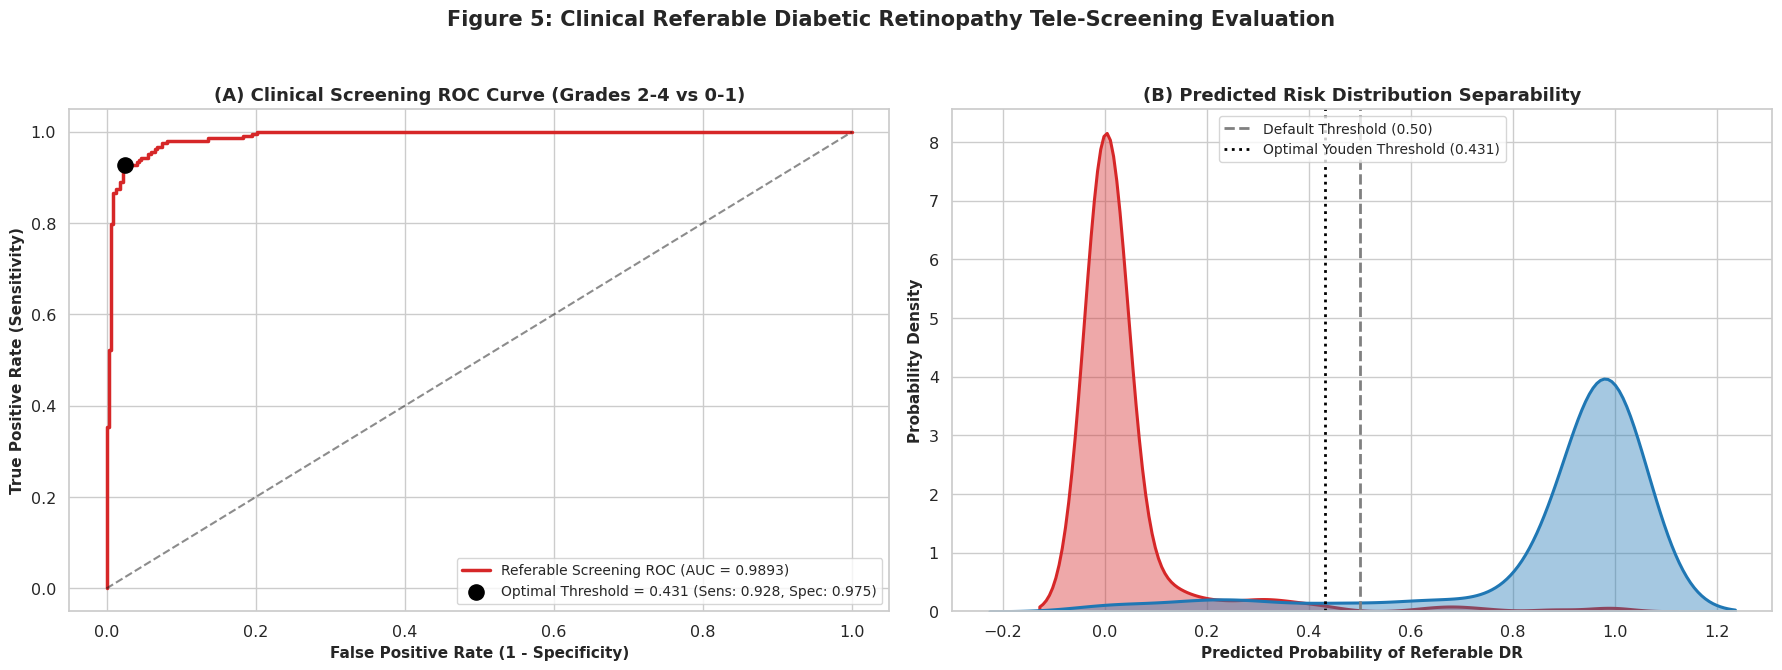

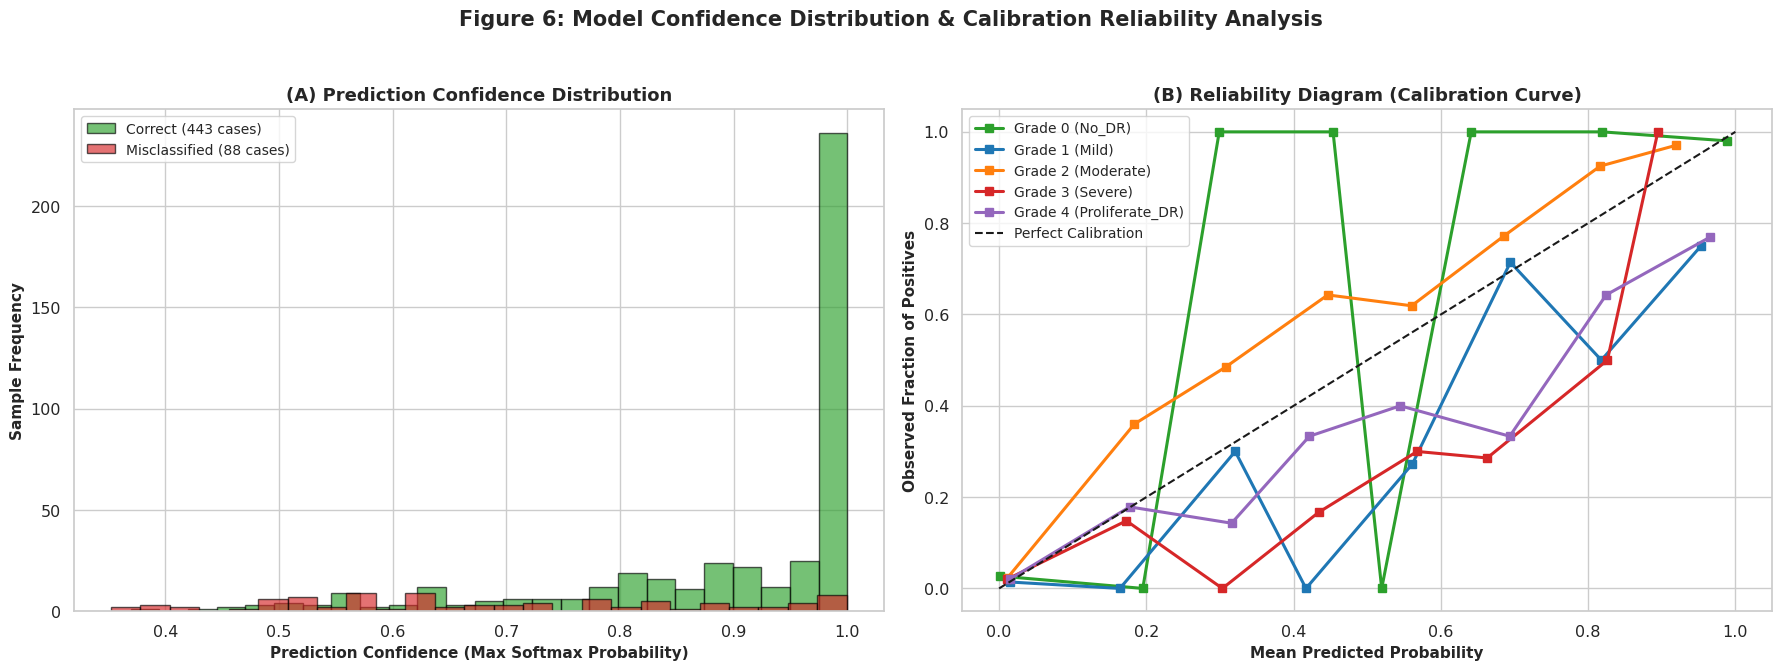

In [ ]:
# Step 13: Setup Graph Directory
os.makedirs("results_graphs", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['font.family'] = 'sans-serif'
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']

# ==========================================
# GRAPH 1: Training & Validation Dynamics
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
epochs_range = range(1, len(history['train_loss']) + 1)

# 1A: Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4', lw=2.2)
axes[0, 0].plot(epochs_range, history['val_loss'], 's--', label='Val Loss', color='#d62728', lw=2.2)
axes[0, 0].set_title('(A) Cross-Entropy Loss Curve', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# 1B: Accuracy
axes[0, 1].plot(epochs_range, [a * 100 for a in history['train_acc']], 'o-', label='Train Accuracy', color='#2ca02c', lw=2.2)
axes[0, 1].plot(epochs_range, [a * 100 for a in history['val_acc']], 's--', label='Val Accuracy', color='#ff7f0e', lw=2.2)
axes[0, 1].set_title('(B) Classification Accuracy Curve (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()

# 1C: Quadratic Weighted Kappa (QWK)
axes[1, 0].plot(epochs_range, history['val_qwk'], '^-', label='Val QWK', color='#9467bd', lw=2.5)
best_idx = np.argmax(history['val_qwk'])
axes[1, 0].scatter(best_idx + 1, history['val_qwk'][best_idx], color='red', s=120, zorder=5, label=f'Peak QWK: {history["val_qwk"][best_idx]:.4f}')
axes[1, 0].set_title('(C) Validation Quadratic Weighted Kappa (QWK)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('QWK Score')
axes[1, 0].legend()

# 1D: Learning Rate Schedule
axes[1, 1].plot(epochs_range, history['lr'], 'd-', color='#8c564b', lw=2.2)
axes[1, 1].set_title('(D) Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')

plt.suptitle('Figure 1: Deep Learning Model Training & Optimization Dynamics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results_graphs/fig1_training_dynamics.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 2: Dual Confusion Matrix Suite
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 2A: Raw Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f"{name}\n(G{i})" for i, name in enumerate(CLASS_NAMES)],
            yticklabels=[f"{name} (G{i})" for i, name in enumerate(CLASS_NAMES)],
            cbar=True, annot_kws={"size": 11, "weight": "bold"})
axes[0].set_title('(A) Raw Sample Counts Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Diagnosis Grade', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Ground Truth Diagnosis Grade', fontsize=11, fontweight='bold')

# 2B: Normalized Percentages
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1],
            xticklabels=[f"{name}\n(G{i})" for i, name in enumerate(CLASS_NAMES)],
            yticklabels=[f"{name} (G{i})" for i, name in enumerate(CLASS_NAMES)],
            cbar=True, annot_kws={"size": 11, "weight": "bold"})
axes[1].set_title('(B) Row-Normalized Percentage Matrix (% per True Class)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Diagnosis Grade', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Ground Truth Diagnosis Grade', fontsize=11, fontweight='bold')

plt.suptitle(f'Figure 2: Confusion Matrix Suite (Overall Accuracy: {acc*100:.2f}% | QWK: {qwk:.4f})',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("results_graphs/fig2_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 3: Multiclass ROC & Precision-Recall
# ==========================================
from sklearn.metrics import average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 3A: Multiclass One-vs-Rest ROC Curves
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    class_auc = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
    axes[0].plot(fpr, tpr, color=colors[i], lw=2.5, label=f"Grade {i} ({CLASS_NAMES[i]}): AUC = {class_auc:.4f}")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_micro = roc_auc_score(y_true_bin, y_probs, average='micro')
axes[0].plot(fpr_micro, tpr_micro, color='black', linestyle=':', lw=2.5, label=f"Micro-Average: AUC = {roc_micro:.4f}")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[0].set_title(f'(A) One-vs-Rest ROC Curves (Macro AUC = {roc_auc_macro:.4f})', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)

# 3B: Precision-Recall Curves with Average Precision (AP)
for i in range(NUM_CLASSES):
    prec_pts, rec_pts, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    axes[1].plot(rec_pts, prec_pts, color=colors[i], lw=2.5, label=f"Grade {i} ({CLASS_NAMES[i]}): AP = {ap:.4f}")

# Plot iso-f1 curves
f_scores = np.linspace(0.4, 0.8, num=3)
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y = f_score * x / (2 * x - f_score)
    axes[1].plot(x[y >= 0], y[y >= 0], color='gray', alpha=0.35, linestyle='--')
    axes[1].annotate(f'f1={f_score:.1f}', xy=(0.88, y[x >= 0.88][0] + 0.02 if len(y[x >= 0.88]) > 0 else 0.5), color='gray', fontsize=8)

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Precision-Recall Curves per DR Grade', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)

plt.suptitle('Figure 3: Multi-Class Discriminative Performance Curves', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("results_graphs/fig3_roc_pr_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 4: Per-Class Diagnostic Comparison
# ==========================================
# Extract metrics per class for side-by-side grouped bar comparison
class_sens = [float(row['Sensitivity (Recall)']) for row in table2_rows]
class_spec = [float(row['Specificity (TNR)']) for row in table2_rows]
class_prec = [float(row['Precision (PPV)']) for row in table2_rows]
class_f1   = [float(row['F1-Score']) for row in table2_rows]

x = np.arange(NUM_CLASSES)
width = 0.20

plt.figure(figsize=(13, 6))
plt.bar(x - 1.5*width, class_sens, width, label='Sensitivity (Recall)', color='#2ca02c', alpha=0.9, edgecolor='black')
plt.bar(x - 0.5*width, class_spec, width, label='Specificity (TNR)', color='#1f77b4', alpha=0.9, edgecolor='black')
plt.bar(x + 0.5*width, class_prec, width, label='Precision (PPV)', color='#ff7f0e', alpha=0.9, edgecolor='black')
plt.bar(x + 1.5*width, class_f1,   width, label='F1-Score', color='#9467bd', alpha=0.9, edgecolor='black')

plt.xlabel('Diabetic Retinopathy Grade', fontsize=12, fontweight='bold')
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.title('Figure 4: Granular Per-Class Diagnostic Metric Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, [f"Grade {i}({CLASS_NAMES[i]})" for i in range(NUM_CLASSES)], fontsize=11, fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(loc='upper right', fontsize=11, ncol=4)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("results_graphs/fig4_per_class_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 5: Clinical Referable DR Screening Analysis
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

# 5A: Referable DR Screening ROC Curve with Youden's J Threshold
fpr_bin, tpr_bin, thresholds = roc_curve(y_true_binary, y_prob_referable)
youden_j = tpr_bin - fpr_bin
opt_idx = np.argmax(youden_j)
opt_thresh = thresholds[opt_idx]

axes[0].plot(fpr_bin, tpr_bin, color='#d62728', lw=2.5, label=f'Referable Screening ROC (AUC = {bin_auc:.4f})')
axes[0].scatter(fpr_bin[opt_idx], tpr_bin[opt_idx], color='black', s=120, zorder=5,
                label=f'Optimal Threshold = {opt_thresh:.3f} (Sens: {tpr_bin[opt_idx]:.3f}, Spec: {1-fpr_bin[opt_idx]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[0].set_title('(A) Clinical Screening ROC Curve (Grades 2-4 vs 0-1)', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)

# 5B: Predicted Referable Probability Distributions
df_screening = pd.DataFrame({
    'True_Status': ['Referable DR (Grades 2-4)' if t == 1 else 'Non-Referable (Grades 0-1)' for t in y_true_binary],
    'Predicted_Referable_Prob': y_prob_referable
})

sns.kdeplot(data=df_screening, x='Predicted_Referable_Prob', hue='True_Status',
            common_norm=False, fill=True, alpha=0.4, palette=['#1f77b4', '#d62728'], ax=axes[1], lw=2.2)
axes[1].axvline(0.5, color='gray', linestyle='--', lw=2, label='Default Threshold (0.50)')
axes[1].axvline(opt_thresh, color='black', linestyle=':', lw=2, label=f'Optimal Youden Threshold ({opt_thresh:.3f})')
axes[1].set_xlabel('Predicted Probability of Referable DR', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Probability Density', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Predicted Risk Distribution Separability', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper center', fontsize=10)

plt.suptitle('Figure 5: Clinical Referable Diabetic Retinopathy Tele-Screening Evaluation',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("results_graphs/fig5_clinical_screening_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 6: Model Calibration & Uncertainty Analysis
# ==========================================
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

# 6A: Confidence Distribution for Correct vs Misclassified
max_probs = np.max(y_probs, axis=1)
is_correct = (y_true == y_pred)

axes[0].hist(max_probs[is_correct], bins=25, alpha=0.65, color='#2ca02c', label=f'Correct ({np.sum(is_correct)} cases)', edgecolor='black')
axes[0].hist(max_probs[~is_correct], bins=25, alpha=0.65, color='#d62728', label=f'Misclassified ({np.sum(~is_correct)} cases)', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence (Max Softmax Probability)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Sample Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('(A) Prediction Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)

# 6B: Multiclass Calibration Reliability Curves (OvR)
for i in range(NUM_CLASSES):
    prob_true, prob_pred = calibration_curve(y_true_bin[:, i], y_probs[:, i], n_bins=8)
    axes[1].plot(prob_pred, prob_true, 's-', color=colors[i], lw=2.2, label=f"Grade {i} ({CLASS_NAMES[i]})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect Calibration')
axes[1].set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Observed Fraction of Positives', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Reliability Diagram (Calibration Curve)', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Figure 6: Model Confidence Distribution & Calibration Reliability Analysis',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("results_graphs/fig6_calibration_analysis.png", dpi=300, bbox_inches='tight')
plt.show()


---
## Step 14: Qualitative Visual Error & Success Analysis
We inspect test images displaying:
- Fundus retina image
- Ground truth diagnosis vs model prediction
- Softmax probability confidence score
- Indicator whether the classification was correct or an error.


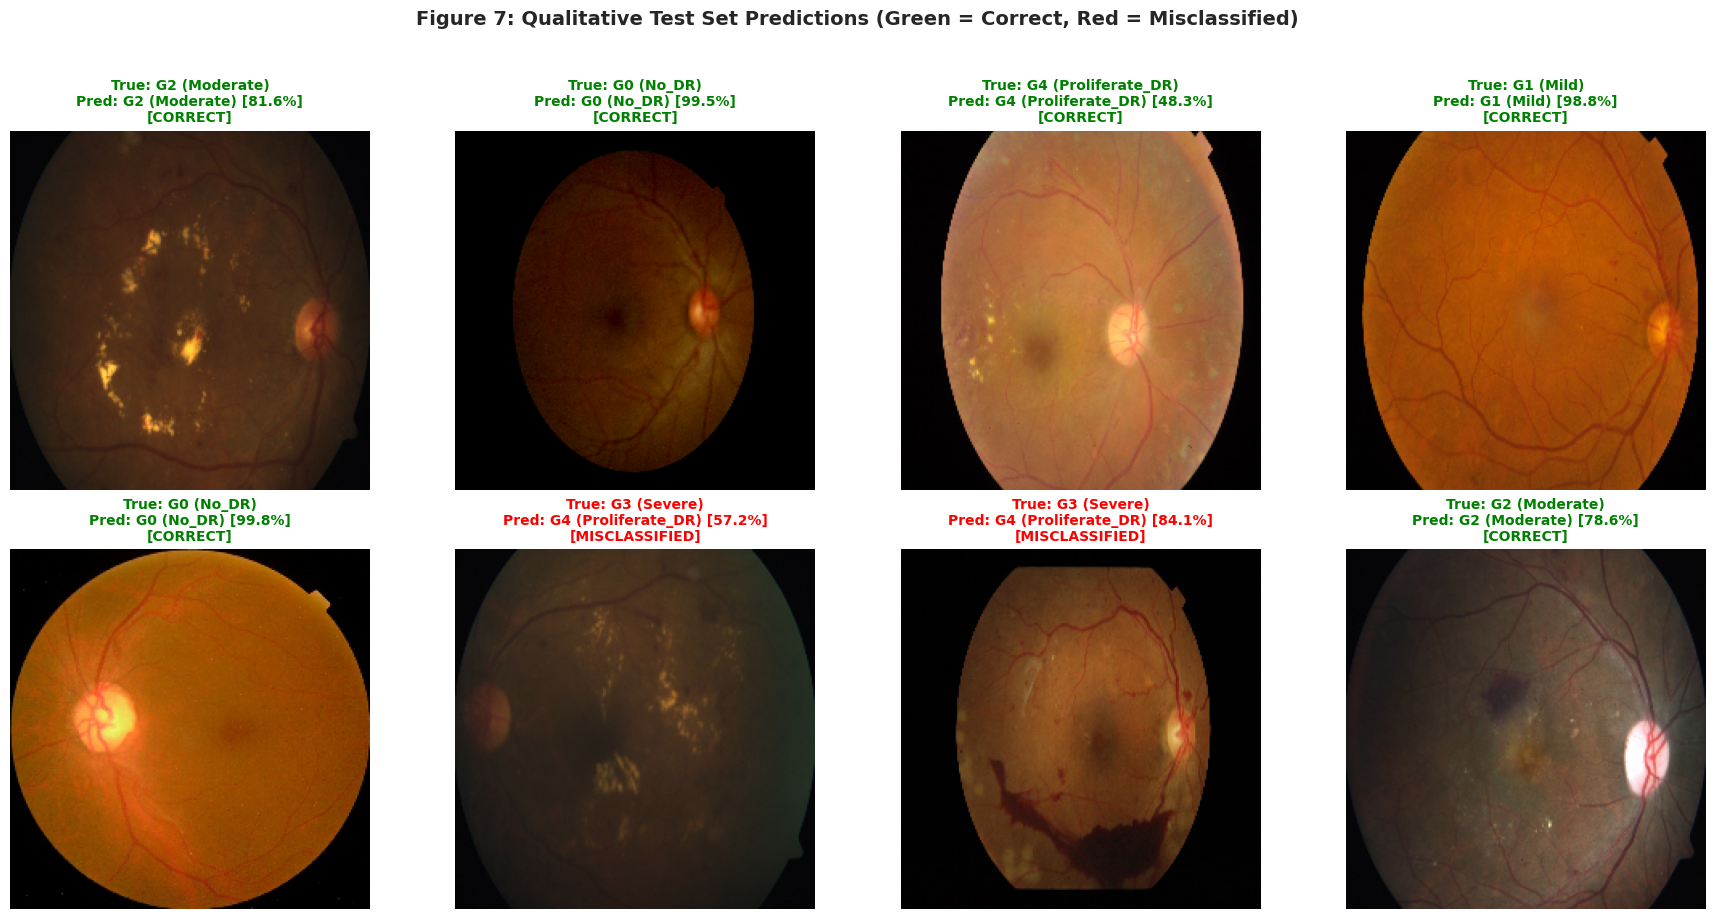

In [ ]:
# Step 14: Display Qualitative Predictions
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
sample_indices = random.sample(range(len(test_dataset)), 8)

for plot_idx, sample_idx in enumerate(sample_indices):
    ax = axes[plot_idx // 4, plot_idx % 4]

    row = test_df.iloc[sample_idx]
    orig_img = Image.open(row['filepath']).convert('RGB')

    actual_grade = y_true[sample_idx]
    pred_grade = y_pred[sample_idx]
    conf = y_probs[sample_idx, pred_grade] * 100

    is_correct = (actual_grade == pred_grade)
    title_color = 'green' if is_correct else 'red'

    ax.imshow(orig_img)
    ax.set_title(f"True: G{actual_grade} ({CLASS_NAMES[actual_grade]})\n"
                 f"Pred: G{pred_grade} ({CLASS_NAMES[pred_grade]}) [{conf:.1f}%]\n"
                 f"{'[CORRECT]' if is_correct else '[MISCLASSIFIED]'}",
                 fontsize=10, fontweight='bold', color=title_color)
    ax.axis('off')

plt.suptitle('Figure 7: Qualitative Test Set Predictions (Green = Correct, Red = Misclassified)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results_graphs/fig7_qualitative_predictions.png", dpi=300, bbox_inches='tight')
plt.show()


## Final Step: Export Model Weights for Knowledge Layer

Run this cell **after training completes** to:
1. Verify `best_dr_model.pth` exists (or save from in-memory model if needed)
2. Save a backup to Google Drive (`My Drive/knowledge_layer_models/`)
3. Download `best_dr_model.pth` directly to your local computer

Once downloaded, place the file in:
`knowledge_layer/models/best_dr_model.pth`


In [ ]:
# ── Export trained model for Knowledge Layer ─────────────────────────────────
import os
import shutil
from pathlib import Path

_pth_name = "best_dr_model.pth"
_pth_src = Path("checkpoint_path") if "checkpoint_path" in globals() else Path(_pth_name)

# Safeguard: if checkpoint wasn't saved on disk, save current in-memory model
if not _pth_src.exists():
    print(f"Notice: {_pth_src} not found on disk. Checking in-memory model...")
    if 'model' in globals():
        import torch
        torch.save({'model_state_dict': model.state_dict()}, _pth_name)
        _pth_src = Path(_pth_name)
        print(f"Saved in-memory PyTorch model to: {_pth_src.resolve()}")
    elif 'pipeline_artifact' in globals():
        import joblib
        joblib.dump(pipeline_artifact, _pth_name)
        _pth_src = Path(_pth_name)
        print(f"Saved in-memory joblib artifact to: {_pth_src.resolve()}")
    else:
        raise FileNotFoundError(
            f"{_pth_src} not found. Please run the training cell above first."
        )

_size_mb = _pth_src.stat().st_size / (1024 * 1024)
print(f"✓ Checkpoint ready: {_pth_src.resolve()} ({_size_mb:.2f} MB)")

# ── Option A: Save to Google Drive (recommended backup) ──────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_dir = Path('/content/drive/MyDrive/knowledge_layer_models')
    _drive_dir.mkdir(parents=True, exist_ok=True)
    _dst = _drive_dir / _pth_name
    shutil.copy2(_pth_src, _dst)
    print(f"✓ Saved to Google Drive: {_dst}")
except Exception as _e:
    print(f"ℹ Google Drive export skipped or not available ({_e})")

# ── Option B: Direct Browser Download ────────────────────────────────────────
try:
    from google.colab import files
    print(f"Starting browser download for {_pth_name}...")
    files.download(str(_pth_src))
    print("✓ Download triggered in browser.")
except Exception as _e:
    print(f"ℹ Colab direct download unavailable ({_e})")
    print(f"  You can manually download {_pth_src.name} from Colab's left sidebar file explorer.")

print(f"\n=======================================================")
print(f"NEXT STEP: Move '{_pth_name}' into your project folder:")
print(f"  knowledge_layer/models/{_pth_name}")
print(f"=======================================================")
